# Low correlation, $S_{1/2}$
*Warning:* shape of cl_Planck = (Nmaps, Nmasks, lmax)

ToDo:
- Compare Smu (summation) to Smu (Itab) with current setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import sys
from scipy.special import legendre
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sys.path.insert(1, '../../scripts')
import CMBanom

In [2]:
# Parameters
Nsims = 100000
Nside = 128
load_stats_from_cluster = True

In [3]:
# Directories
sims_dir = '../../data/sims/sims_1k/'
real_dir = "../../data/real/"
stats_dir = "../../data/stats/"

# Planck maps  
labels_Planck = [r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$", r"$70\, \mathrm{GHz}$", r"$94\, \mathrm{GHz}$", r"$100\, \mathrm{GHz}$", r"$143\, \mathrm{GHz}$"]
names_Planck  = ["commander", "nilc", "sevem", "smica",   "70GHz",   "94GHz", "100GHz", "143GHz"]
colors        = [  "tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss           = [       "--",   "--",    "--",    "--",       "-",       "-",      "-",      "-"]
color_qml     = "olive"
label_qml     = r"$\mathrm{Public\ QML-}C_\ell$"
index_Planck  = 0
index_Hayley  = 6
Nmaps = len(names_Planck)

# Masks
names_mask  = [              "fullsky",                "stdmask",                  "commask"]
labels_mask = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask = [                 "navy",              "firebrick",                 "tab:blue"]
Nmasks = len(names_mask)

# Cls
fn_cl_theory = "../../data/Cls/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt"
fn_cl_qml    = "../../data/Cls/COM_PowerSpect_CMB-TT-full_R3.01.txt"

In [4]:
# Font
plt.rc('font',**{'family':'Helvetica','size':16})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  16}

In [5]:
# Same l-range for all Cls
lmax = 384
ll = np.arange(lmax)

In [6]:
# Load Planck Cl (begins with l=0) and correct window fcts. and units, shape: (Nmasks, Nmaps, lmax)
cl_wf_factor = CMBanom.get_cl_wf_factor(Nside)
cl_Planck = np.array([[np.loadtxt(real_dir+"cl_"+names_Planck[n]+"_"+names_mask[m]+".txt").T[1] for m in range(Nmasks)] for n in range(Nmaps)])
cl_Planck[:4] *= cl_wf_factor
cl_Planck[4:] *= 1e6*cl_wf_factor

# Load Planck corr 
theta, cos_theta = np.loadtxt(real_dir+"corr_"+names_Planck[0]+"_"+names_mask[0]+".txt").T[:2]
corr_Planck = np.array([[np.loadtxt(real_dir+"corr_"+names_Planck[n]+"_"+names_mask[m]+".txt").T[2] for m in range(Nmasks)] for n in range(Nmaps)])
corr_Planck[4:] *= 1e6

In [7]:
# Load theory Cl used to generate (begins with l=2)
dl_theory = np.append(np.zeros(2), np.loadtxt(fn_cl_theory, skiprows=1).T[1])[:lmax]

In [8]:
# Load QML Cl's (begins with l=2)
dl_qml = np.loadtxt(fn_cl_qml).T[1][:lmax-2]
cl_qml = np.append(np.zeros(2), dl_qml/ll[2:]/(1+ll[2:])*2*np.pi)

# Compute C(theta) from QML Cl's
corr_qml = np.array([CMBanom.corr_from_cl(t, cl_qml) for t in theta])

In [9]:
# Get sim envelope
if load_stats_from_cluster:
    mean_corrs = np.array([np.loadtxt(stats_dir+"corr_mean_std_"+names_mask[m]+".npy")[0] for m in range(Nmasks)])
    std_corrs = np.array([np.loadtxt(stats_dir+"corr_mean_std_"+names_mask[m]+".npy")[1] for m in range(Nmasks)])
else: 
    cls,corrs = np.zeros((Nmasks, Nsims, lmax)), np.zeros((Nmasks, Nsims, lmax))
    for m in range(Nmasks):
        corrs[m] = CMBanom.load_corrs(sims_dir, names_mask[m], Nsims)[2]
    mean_corrs = np.mean(corrs, axis=1)
    std_corrs = np.std(corrs, axis=1)

## Plot $C(\theta)$

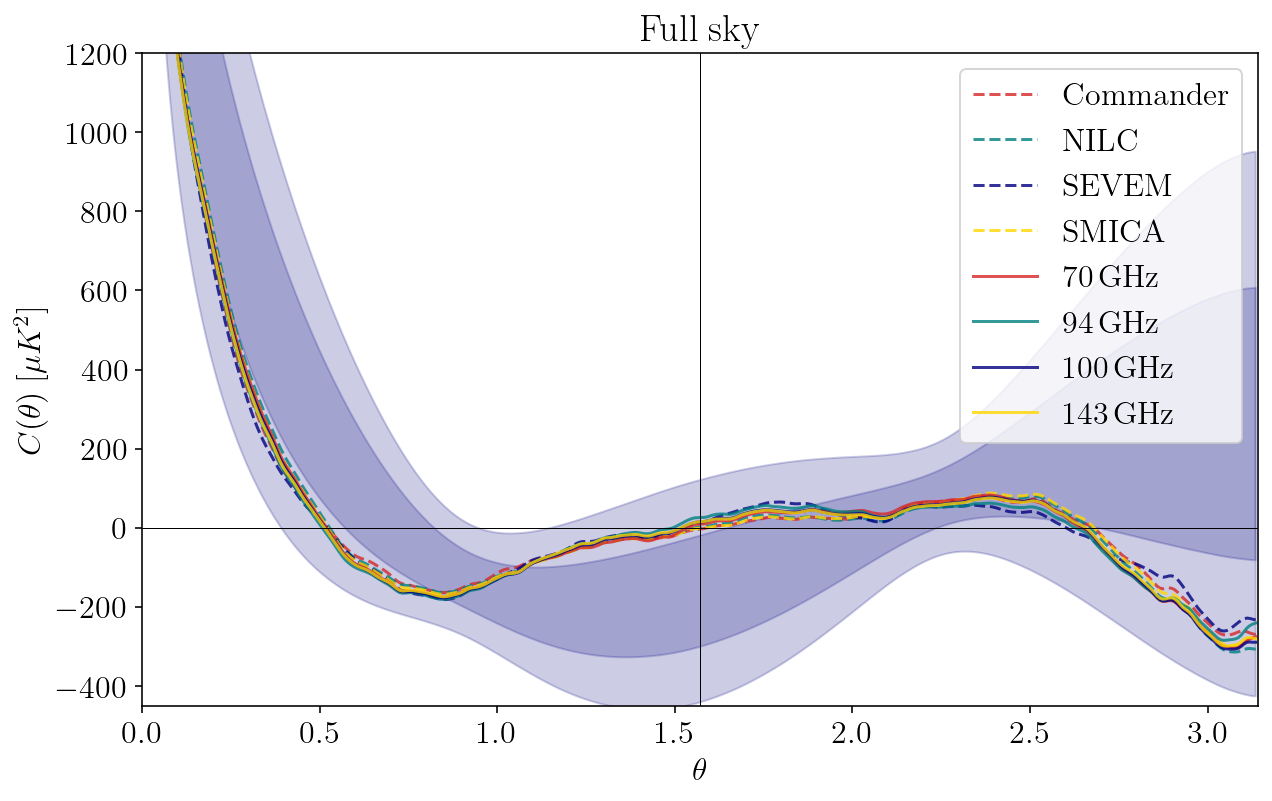

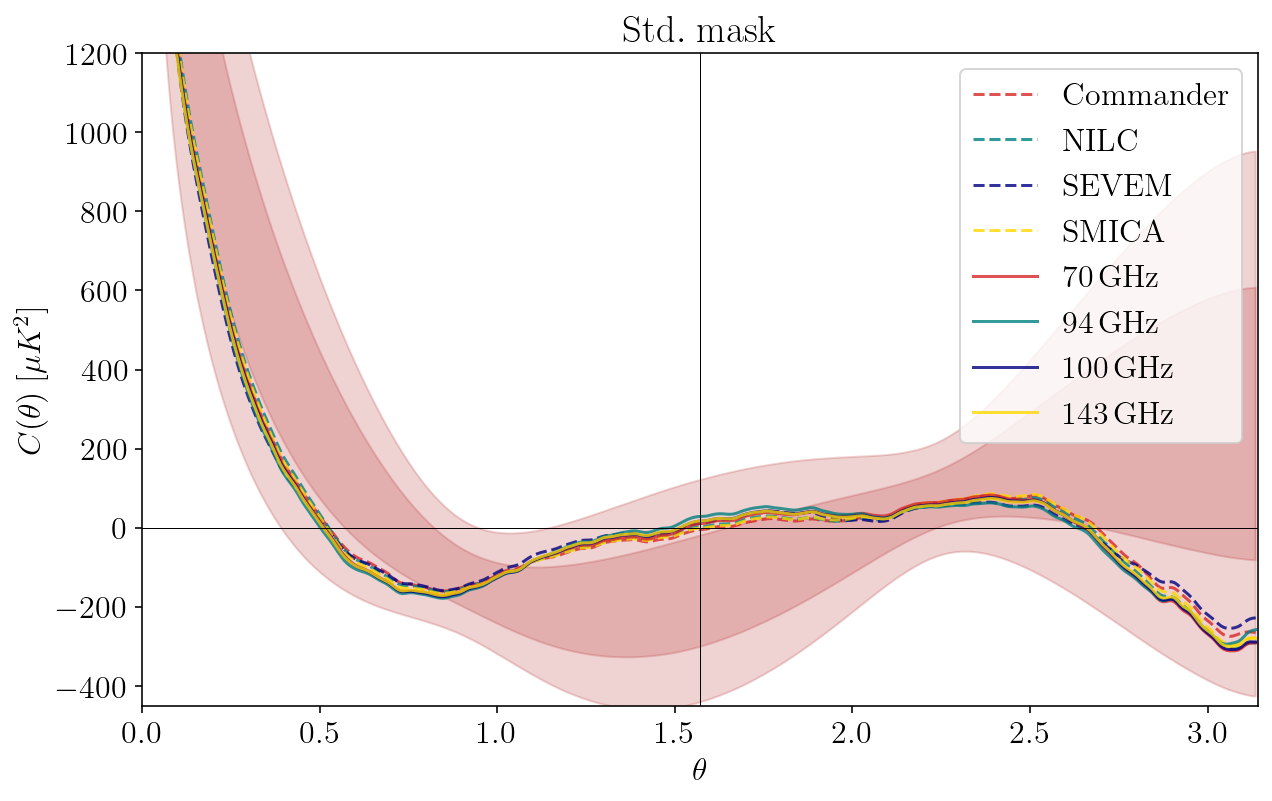

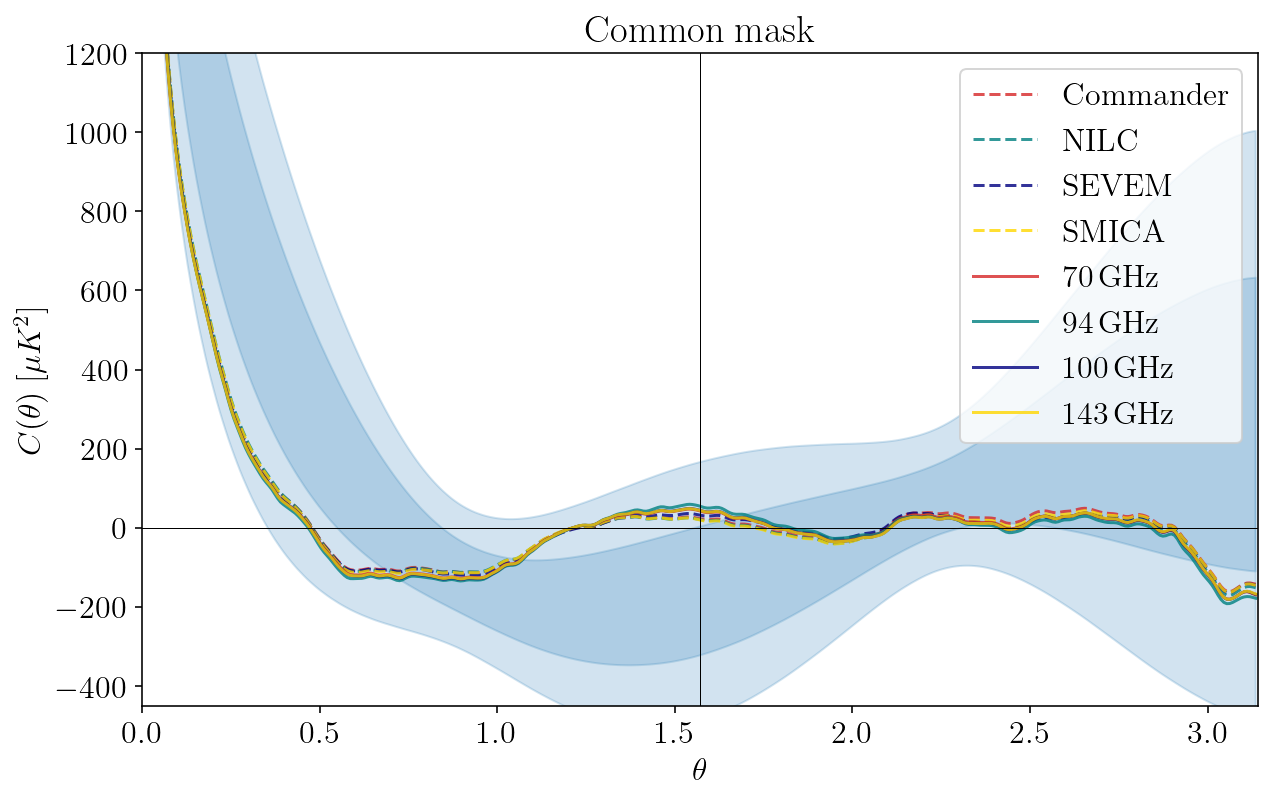

In [18]:
for m in range(Nmasks):
    fig = plt.figure(figsize=(10, 6))
    for n in range(Nmaps):
        plt.plot(theta, corr_Planck[n][m], label=labels_Planck[n], ls=lss[n], color=colors[n], alpha=0.8)
    plt.fill_between(theta, mean_corrs[m]-std_corrs[m], mean_corrs[m]+std_corrs[m], alpha= 0.2, color=colors_mask[m])
    plt.fill_between(theta, mean_corrs[m]-2*std_corrs[m], mean_corrs[m]+2*std_corrs[m], alpha= 0.2, color=colors_mask[m])
    plt.title(labels_mask[m])
    plt.ylim(-450, 1200)
    plt.xlim(0, np.pi)
    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$C(\theta)\ [\mu K^2]$")
    plt.axhline(0, color="black", lw=0.5)
    plt.axvline(np.pi/2., color="black", lw=0.5)
    plt.legend()
    plt.show()

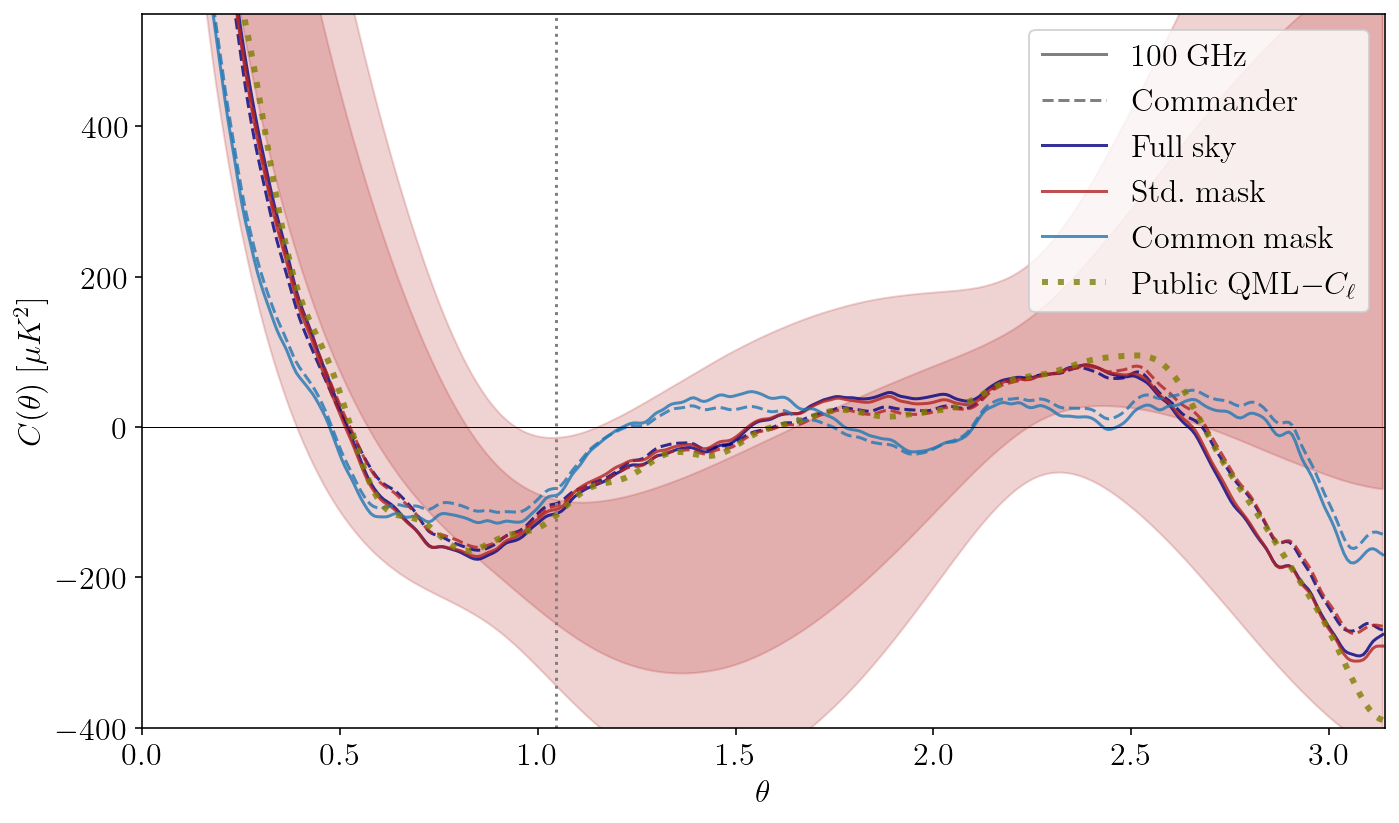

In [11]:
fig = plt.figure(figsize=(10, 6))
plt.plot([0], [0], color='grey', ls="-", label=r'$100\ \mathrm{GHz}$')
plt.plot([0], [0], color='grey', ls="--", label=r'$\mathrm{Commander}$')
for m in range(Nmasks):
    plt.plot(theta, corr_Planck[4][m], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m])
    plt.plot(theta, corr_Planck[0][m], color=colors_mask[m], alpha=0.8, ls="--")
m = 1
plt.fill_between(theta, mean_corrs[m]-std_corrs[m], mean_corrs[m]+std_corrs[m], alpha= 0.2, color=colors_mask[m])
plt.fill_between(theta, mean_corrs[m]-2*std_corrs[m], mean_corrs[m]+2*std_corrs[m], alpha= 0.2, color=colors_mask[m])
plt.plot(theta, corr_qml, color="olive", alpha=0.8, ls=":", lw=3, label=label_qml)
plt.ylim(-400, 550)
plt.xlim(0, np.pi)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$C(\theta)\ [\mu K^2]$")
plt.axhline(0, color="black", lw=0.5)
plt.axvline(60/180*np.pi, color="grey", ls=":")
plt.legend()
plt.tight_layout()
plt.savefig("Corr_fct.pdf", format="PDF")
plt.show()

## Plot $S_{1/2}$

In [12]:
if load_stats_from_cluster:
    Smu_sims = [np.loadtxt(stats_dir+f"Smu_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)]
else:
    Smu_sims = [CMBanom.S_mu_many(corrs[m], cos_theta, 0.5) for m in range(Nmasks)]
Smu_Planck = [CMBanom.S_mu_many(corr_Planck[n], cos_theta, 0.5) for n in range(Nmaps)]
Smu_Planck_QML = CMBanom.S_mu_many([corr_qml], cos_theta, 0.5)

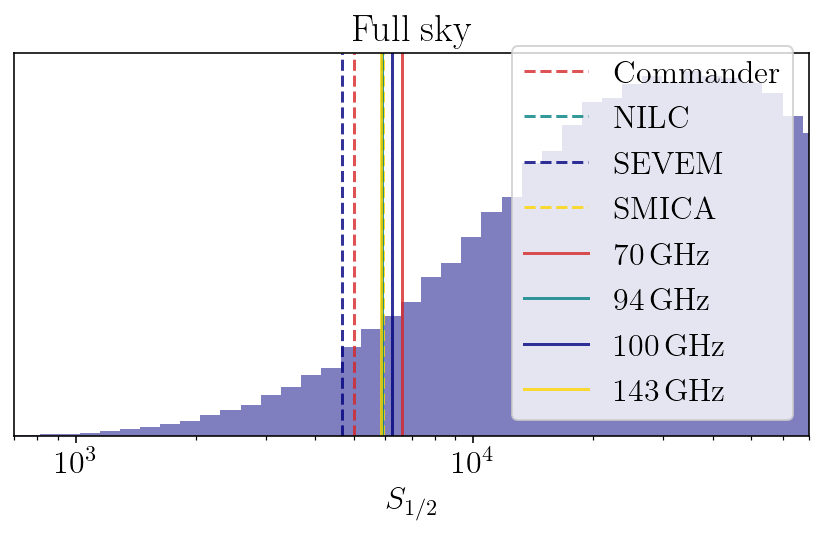

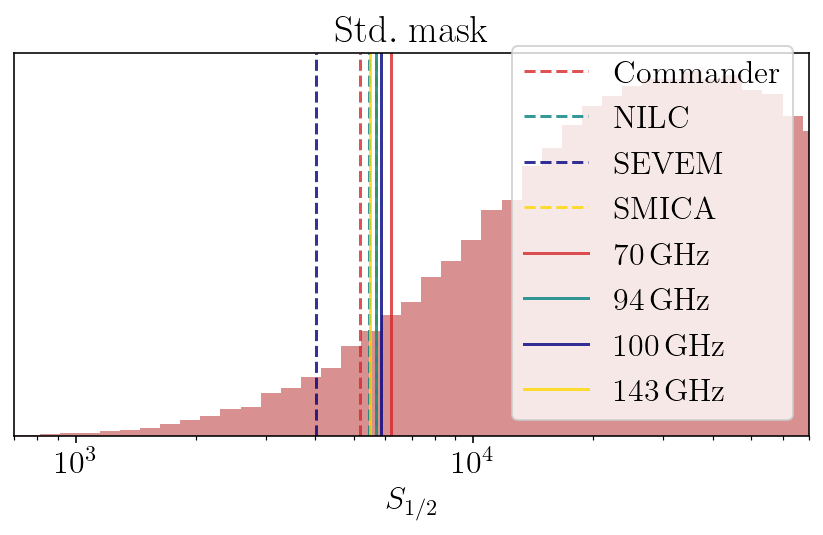

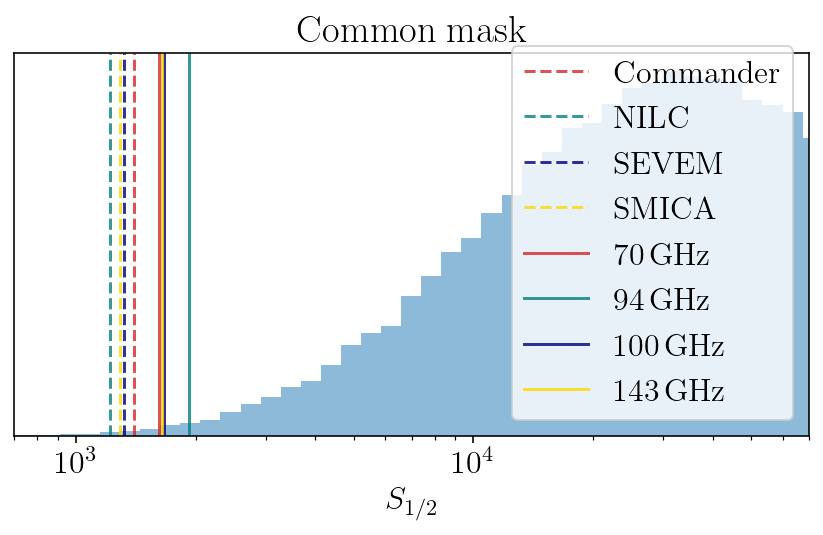

In [13]:
for m in range(Nmasks):
    bins = 10**np.linspace(2, 7, 100)
    h=plt.hist(Smu_sims[m], bins=bins, color=colors_mask[m], alpha=0.5)
    for n in range(Nmaps):
        plt.axvline(Smu_Planck[n][m], color=colors[n], ls=lss[n], label=labels_Planck[n], alpha=0.8)
    plt.title(labels_mask[m])
    plt.xlim(7e2, 7e4)
    plt.xscale("log")
    plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
    plt.xlabel(r"$S_{1/2}$")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("hist_S_12_"+names_mask[m]+".pdf")
    plt.show()

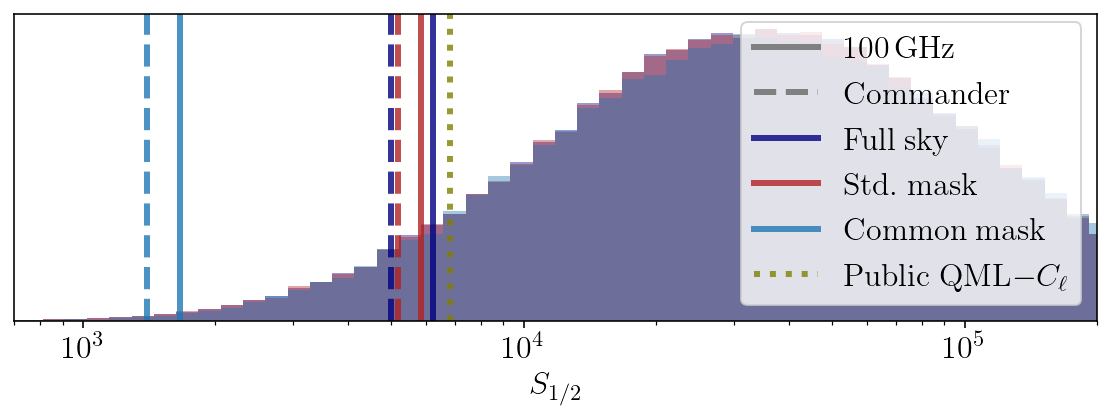

In [14]:
fig = plt.figure(figsize=(8, 3.2))
bins = 10**np.linspace(2, 7, 100)
plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(Smu_sims[m], bins=bins, color=colors_mask[m], alpha=0.4)
    plt.axvline(Smu_Planck[index_Hayley][m], color=colors_mask[m], lw=3, alpha=0.8, ls="-", label=labels_mask[m])
    plt.axvline(Smu_Planck[index_Planck][m], color=colors_mask[m], lw=3, alpha=0.8, ls="--")
plt.axvline(Smu_Planck_QML[0], color=color_qml, lw=3, alpha=0.8, ls=":", label=label_qml)
plt.xlim(7e2, 2e5)
plt.xscale("log")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
plt.xlabel(r"$S_{1/2}$")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("hist_S_12.pdf", format="PDF")
plt.show()

## Compute p-values (in %)

In [15]:
print("-----------")
for m in range(Nmasks):
    print(names_mask[m])
    print("-----------")
    for n in range(Nmaps):
        print(names_Planck[n], 100*CMBanom.pval_lower(Smu_Planck[n][m], Smu_sims[m]))
    print("-----------")

-----------
fullsky
-----------
commander 4.5600000000000005
nilc 6.146
sevem 4.02
smica 6.198
70GHz 7.524
94GHz 6.1850000000000005
100GHz 6.827999999999999
143GHz 6.103
-----------
stdmask
-----------
commander 4.907
nilc 5.4
sevem 2.98
smica 5.804
70GHz 6.7669999999999995
94GHz 5.817
100GHz 6.081
143GHz 5.4670000000000005
-----------
commask
-----------
commander 0.154
nilc 0.096
sevem 0.132
smica 0.12
70GHz 0.25
94GHz 0.422
100GHz 0.27799999999999997
143GHz 0.268
-----------


In [16]:
print("p-values")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{100*CMBanom.pval_lower(Smu_Planck[n][m],Smu_sims[m]):.2f} ", end="")
    print("\\\\")

p-values
fullsky : &4.56 &6.15 &4.02 &6.20 &7.52 &6.19 &6.83 &6.10 \\
stdmask : &4.91 &5.40 &2.98 &5.80 &6.77 &5.82 &6.08 &5.47 \\
commask : &0.15 &0.10 &0.13 &0.12 &0.25 &0.42 &0.28 &0.27 \\


In [17]:
print("stats")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{Smu_Planck[n][m]:.0f} ", end="")
    print("\\\\")

stats
fullsky : &4997 &5879 &4679 &5909 &6615 &5896 &6240 &5849 \\
stdmask : &5198 &5474 &4015 &5690 &6211 &5697 &5842 &5507 \\
commask : &1400 &1217 &1324 &1289 &1617 &1923 &1664 &1650 \\
